In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# 폰트 설정

!apt-get update -qq
!apt-get install -y fonts-nanum

# 설치된 나눔폰트 강제 등록
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns
import os

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumGothic')
    plt.rcParams['axes.unicode_minus'] = False
else:
    print("폰트 파일이 존재하지 않습니다.")


plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 50 not upgraded.


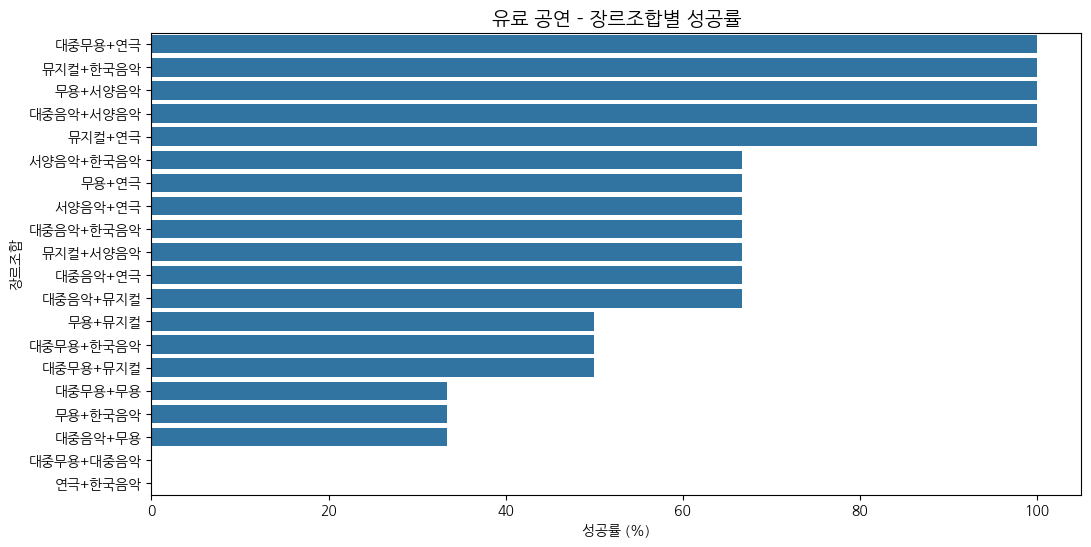

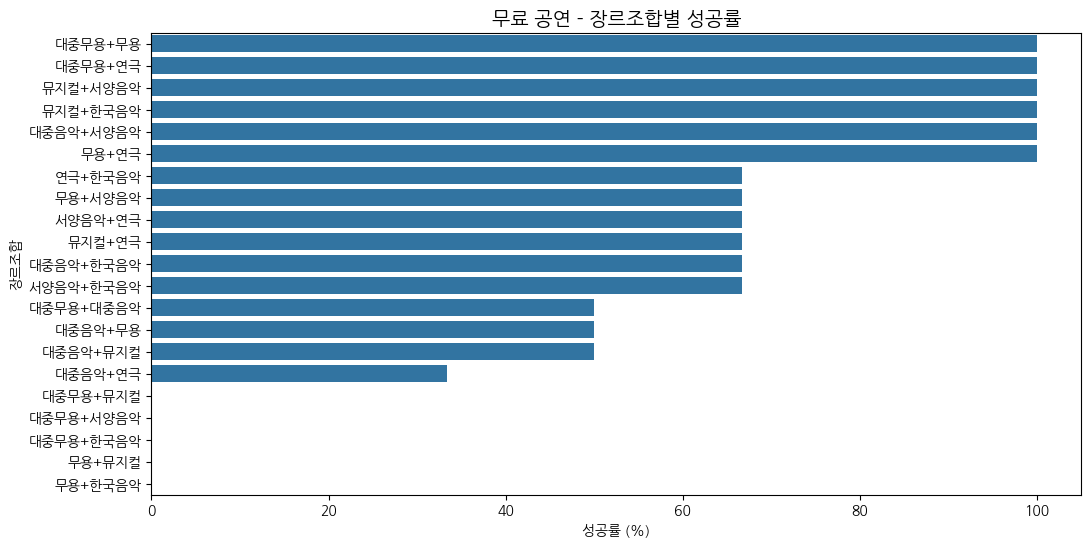

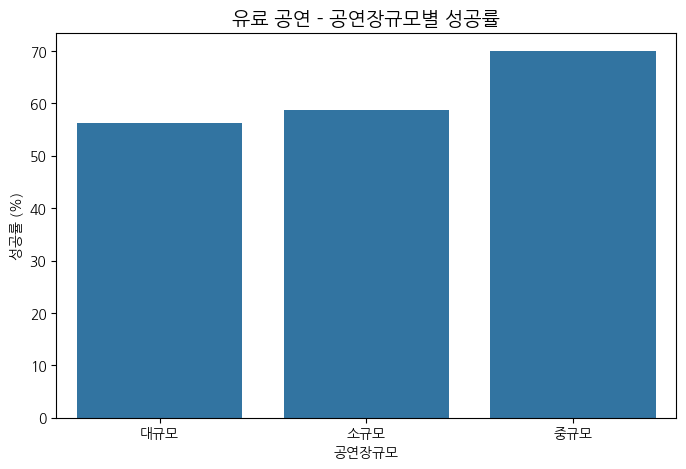

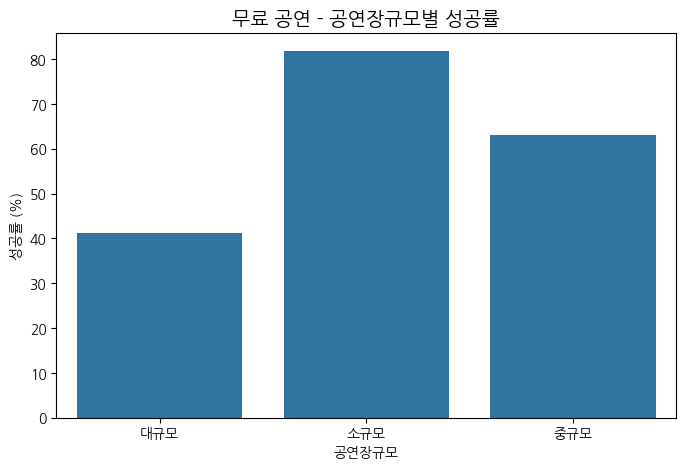

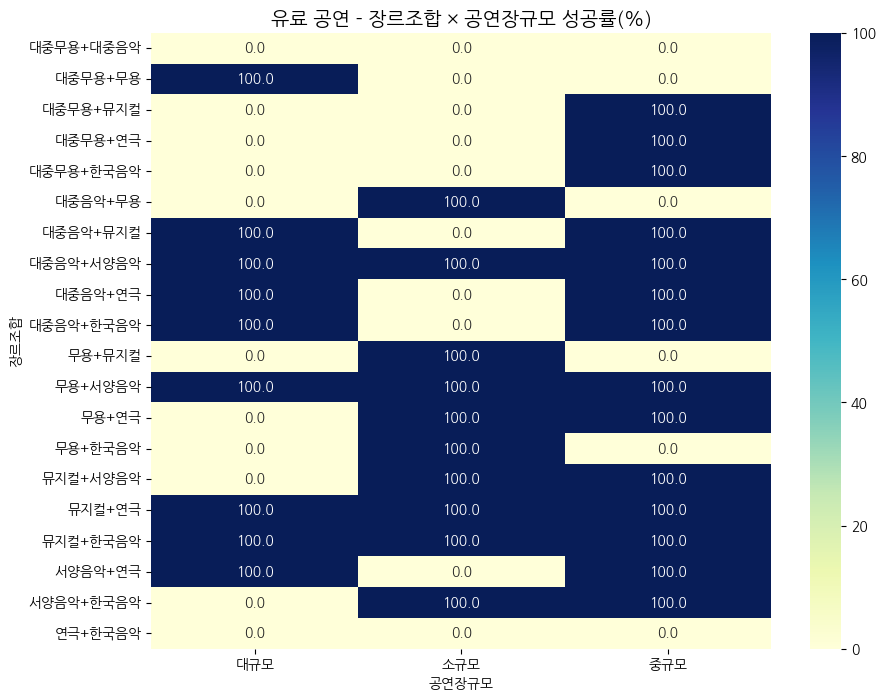

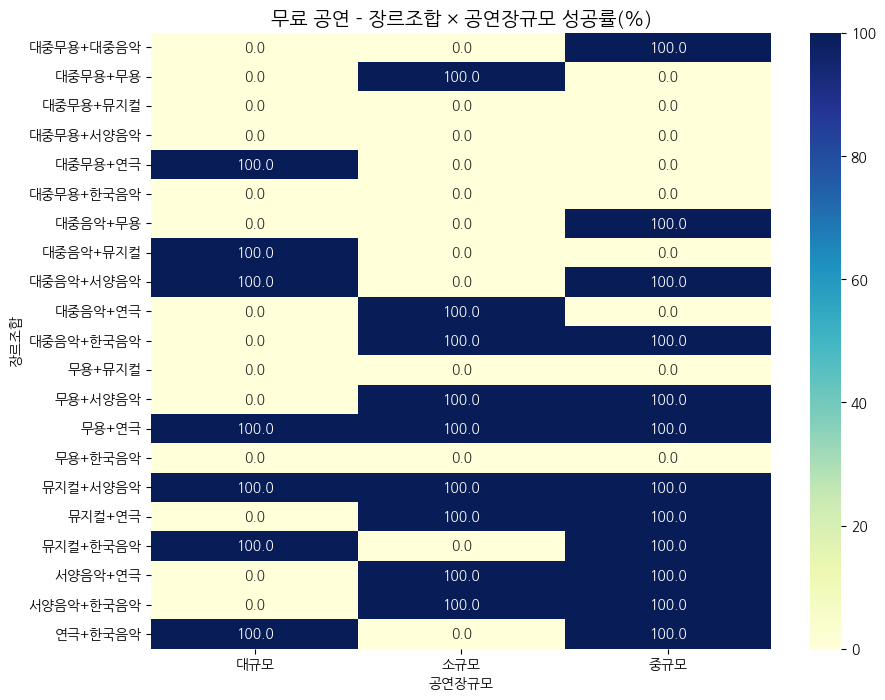

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 📂 CSV 불러오기
df_paid = pd.read_csv("/content/drive/MyDrive/복합_유료_장르조합_비교결과.csv")
df_free = pd.read_csv("/content/drive/MyDrive/복합_무료_장르조합_비교결과.csv")

# ✅ 성공/실패만 필터링 (판정_mean 기준)
df_paid_valid = df_paid[df_paid['판정_mean'].isin(['성공','실패'])]
df_free_valid = df_free[df_free['판정_mean'].isin(['성공','실패'])]

# -------------------------------
# (a) 장르조합별 성공률 막대 그래프
# -------------------------------
def plot_genre_success(df, title):
    stats = df.groupby(["장르조합","판정_mean"]).size().unstack(fill_value=0)
    stats["전체"] = stats.sum(axis=1)
    stats["성공률"] = stats["성공"] / stats["전체"] * 100
    stats = stats.sort_values("성공률", ascending=False)

    plt.figure(figsize=(12,6))
    sns.barplot(x=stats["성공률"], y=stats.index)
    plt.title(title, fontsize=14)
    plt.xlabel("성공률 (%)")
    plt.ylabel("장르조합")
    plt.show()

plot_genre_success(df_paid_valid, "유료 공연 - 장르조합별 성공률")
plot_genre_success(df_free_valid, "무료 공연 - 장르조합별 성공률")

# -------------------------------
# (b) 공연장 규모별 성공률 막대 그래프
# -------------------------------
def plot_venue_success(df, title):
    stats = df.groupby(["공연장규모","판정_mean"]).size().unstack(fill_value=0)
    stats["전체"] = stats.sum(axis=1)
    stats["성공률"] = stats["성공"] / stats["전체"] * 100

    plt.figure(figsize=(8,5))
    sns.barplot(x=stats.index, y=stats["성공률"])
    plt.title(title, fontsize=14)
    plt.ylabel("성공률 (%)")
    plt.xlabel("공연장규모")
    plt.show()

plot_venue_success(df_paid_valid, "유료 공연 - 공연장규모별 성공률")
plot_venue_success(df_free_valid, "무료 공연 - 공연장규모별 성공률")

# -------------------------------
# (c) 성공률 히트맵 (장르조합 × 공연장규모)
# -------------------------------
def plot_heatmap(df, title):
    stats = df.groupby(["장르조합","공연장규모","판정_mean"]).size().unstack(fill_value=0)
    stats["전체"] = stats.sum(axis=1)
    stats["성공률"] = stats["성공"] / stats["전체"] * 100
    pivot = stats.reset_index().pivot(index="장르조합", columns="공연장규모", values="성공률").fillna(0)

    plt.figure(figsize=(10,8))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")
    plt.title(title, fontsize=14)
    plt.show()

plot_heatmap(df_paid_valid, "유료 공연 - 장르조합 × 공연장규모 성공률(%)")
plot_heatmap(df_free_valid, "무료 공연 - 장르조합 × 공연장규모 성공률(%)")


## RandomForest 모델


In [14]:
# 필요한 컬럼만 추출
features = ["U_participation", "S_scale", "A_afford"]
target = "DPI_plus"

X_paid = df_paid[features]
y_paid = df_paid[target]

X_free = df_free[features]
y_free = df_free[target]


### 모델 학습 (Random Forest) - 유료 공연

In [15]:
# 모델 불러오기
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X_paid, y_paid, test_size=0.2, random_state=42)

In [16]:
# 모델학습
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [17]:
# 평가
y_pred = rf.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 18.116278462708358
R2: 0.9209576189255013


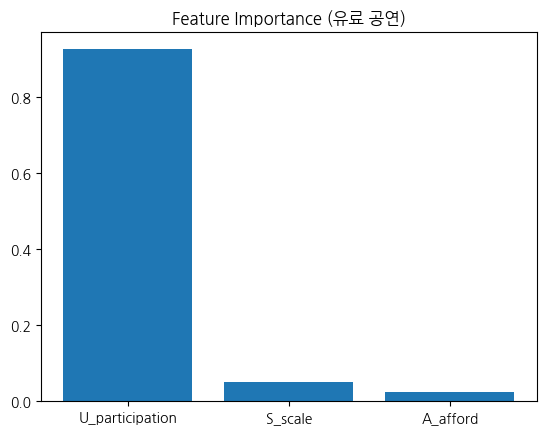

In [18]:
# 변수 중요도 확인
import matplotlib.pyplot as plt

importances = rf.feature_importances_
plt.bar(features, importances)
plt.title("Feature Importance (유료 공연)")
plt.show()

실패 조합 DPI 개선 시뮬레이션 - 유료 공연

In [19]:
# 실패 사례 추출
fail_paid = df_paid[df_paid['판정_mean'] == '실패'].copy()

# 실패 사례 예측값 VS 실제값 비교
fail_paid["예측_DPI"] = rf.predict(fail_paid[features])

In [20]:
# 개선 시뮬레이션
#각 실패 사례에서 U/S/A를 각각 +0.1씩 높여서 다시 예측
# 개선된 DPI - 원래 DPI = 향상 효과 계산

for col in features:
    improved = fail_paid[features].copy()
    improved[col] = improved[col] + 0.1  # +0.1 개선 가정
    fail_paid[f"{col}_개선DPI"] = rf.predict(improved)
    fail_paid[f"{col}_향상폭"] = fail_paid[f"{col}_개선DPI"] - fail_paid["예측_DPI"]

In [ ]:
# 결과 저장
fail_paid.to_csv("유료_실패사례_DPI개선시뮬레이션.csv", index=False, encoding="utf-8-sig")

위에는 각각의 특성을 살려서 진행. 유료 공연만 진행하였고, 무료 공연을 합쳐서 아래 동시에 진행하였음



=== 유료 공연 모델 평가 ===
MSE: 18.116278462708358
R2: 0.9209576189255013


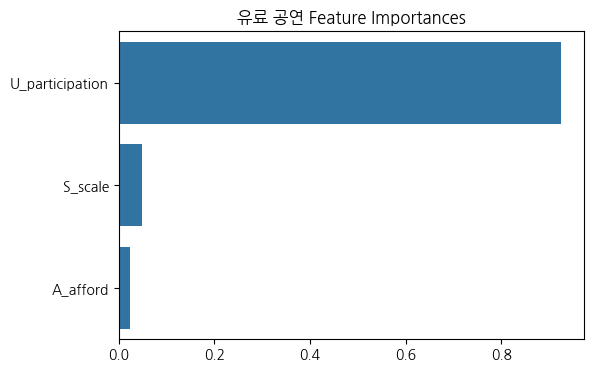

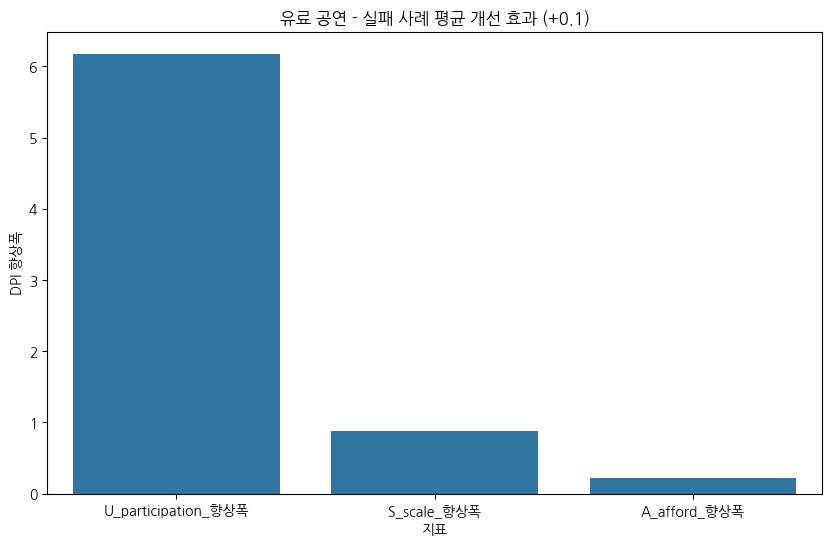

=== 무료 공연 모델 평가 ===
MSE: 20.81083697150771
R2: 0.8784701869487987


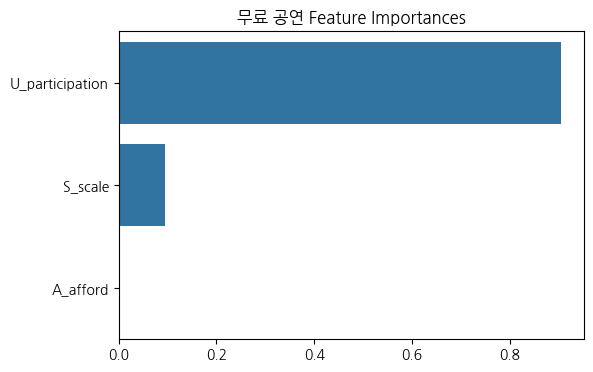

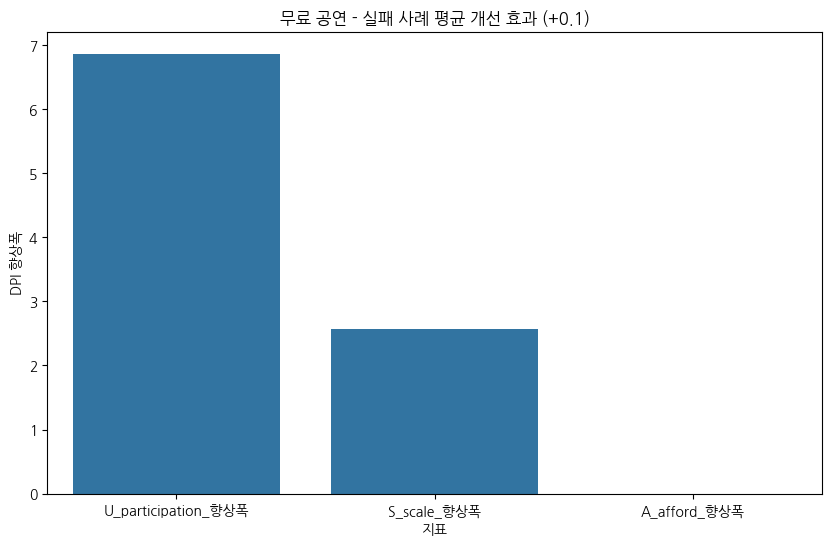

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

features = ["U_participation", "S_scale", "A_afford"]
target = "DPI_plus"

# -------------------------------
# 🔹 함수 정의: 학습 + 시뮬레이션
# -------------------------------
def run_rf_analysis(df, label):
    # 1. 학습 데이터
    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. 모델 학습
    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X_train, y_train)

    # 3. 평가
    y_pred = rf.predict(X_test)
    print(f"=== {label} 모델 평가 ===")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

    # 4. 변수 중요도 시각화
    importances = rf.feature_importances_
    plt.figure(figsize=(6,4))
    sns.barplot(x=importances, y=features)
    plt.title(f"{label} Feature Importances")
    plt.show()

    # 5. 실패 사례 추출
    fails = df[df['판정_mean'] == '실패'].copy()
    fails["예측_DPI"] = rf.predict(fails[features])

    # 6. 개선 시뮬레이션 (+0.1씩 올림)
    for col in features:
        improved = fails[features].copy()
        improved[col] = improved[col] + 0.1
        fails[f"{col}_개선DPI"] = rf.predict(improved)
        fails[f"{col}_향상폭"] = fails[f"{col}_개선DPI"] - fails["예측_DPI"]

    # 7. 시각화: 실패 사례별 U/S/A 개선 효과
    plt.figure(figsize=(10,6))
    improvement = fails[[f"{col}_향상폭" for col in features]].mean().reset_index()
    improvement.columns = ["지표","평균 향상폭"]
    sns.barplot(data=improvement, x="지표", y="평균 향상폭")
    plt.title(f"{label} - 실패 사례 평균 개선 효과 (+0.1)")
    plt.ylabel("DPI 향상폭")
    plt.show()

    return fails

# -------------------------------
# 🔹 실행 (유료 / 무료)
# -------------------------------
fails_paid = run_rf_analysis(df_paid, "유료 공연")
fails_free = run_rf_analysis(df_free, "무료 공연")

# 실패 사례별 결과 저장 (원하면 코랩에서 확인 가능)
fails_paid.to_csv("유료_실패사례_DPI개선시뮬레이션.csv", index=False, encoding="utf-8-sig")
fails_free.to_csv("무료_실패사례_DPI개선시뮬레이션.csv", index=False, encoding="utf-8-sig")
